In [1]:
from utility import load_test_results, architecture_stats, sample_image

from NeuralNetwork import NeuralNetwork, torch

In [2]:
classifiers_dict, all_results = load_test_results("Classifier_3")

In [3]:
classifiers_dict

{0: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2'])",
 1: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv3', 'FC1'])",
 2: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2', 'Conv3', 'FC1'])",
 3: 'Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=[])',
 4: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv3'])",
 5: 'Classifier_3 (n_neurons_molt_factor=1, do_dropout=[])',
 6: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['FC1'])",
 7: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2', 'Conv3'])",
 8: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['FC1'])",
 9: 'Classifier_3 (n_neurons_molt_factor=2, do_dropout=[])',
 10: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2'])",
 11: "Classifier_3 (n_neurons_molt_factor=1, do_dropout=['FC1'])",
 12: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv3'])",
 13: "Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv3'])",
 14: "Classifier_3 (n_neurons_m

In [4]:
all_results.head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,optimizer,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,2.0,['Conv2'],AMSGrad,0.0005,32,5,0.00,0.020078,0.082985,10.274774
1,1,0,2.0,['Conv2'],AMSGrad,0.0005,32,5,0.25,0.020078,0.082584,5.663384
2,2,0,2.0,['Conv2'],AMSGrad,0.0005,32,5,0.50,0.020078,0.082888,6.735712
3,3,0,2.0,['Conv2'],AMSGrad,0.0005,32,5,0.75,0.020078,0.082331,31.197771
4,4,0,2.0,['Conv2'],AMSGrad,0.0005,32,10,0.00,0.020078,0.082214,8.450551
5,5,0,2.0,['Conv2'],AMSGrad,0.0005,32,10,0.25,0.020078,0.082479,10.368641
6,6,0,2.0,['Conv2'],AMSGrad,0.0005,32,10,0.50,0.020078,0.082609,12.337944
7,7,0,2.0,['Conv2'],AMSGrad,0.0005,32,10,0.75,0.020078,0.082693,14.279868
8,8,0,2.0,['Conv2'],AMSGrad,0.0005,32,15,0.00,0.020078,0.082699,12.273641
9,9,0,2.0,['Conv2'],AMSGrad,0.0005,32,15,0.25,0.020078,0.082577,15.146993


In [5]:
all_results.sort_values(by=['test_accuracies'], ascending=False).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,optimizer,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
13968,528,21,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,256,5,0.00,1.0,0.043967,7.486076
14071,631,21,1.0,"['Conv2', 'Conv3']",ADAM,0.000001,512,10,0.75,1.0,0.041062,7.141269
13978,538,21,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,256,15,0.50,1.0,0.043962,9.642871
13977,537,21,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,256,15,0.25,1.0,0.043979,8.063980
13976,536,21,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,256,15,0.00,1.0,0.043876,9.869764
13974,534,21,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,256,10,0.50,1.0,0.044028,6.615187
13973,533,21,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,256,10,0.25,1.0,0.043954,5.621310
13972,532,21,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,256,10,0.00,1.0,0.043928,5.835711
13971,531,21,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,256,5,0.75,1.0,0.043901,4.195493
13970,530,21,1.0,"['Conv2', 'Conv3']",ADAM,0.000010,256,5,0.50,1.0,0.043874,3.627492


In [6]:
n_high_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].max()])
n_high_accuracy_architectures

1164

In [7]:
high_accuracy_architectures = all_results.sort_values(by=['test_accuracies'], ascending=False).head(n_high_accuracy_architectures)["architecture_id"].unique()
high_accuracy_architectures

array([21, 14, 15, 13,  2, 10, 22,  7, 18, 19, 20, 17, 23])

In [8]:
for model in high_accuracy_architectures:
    architecture_stats(all_results, classifiers_dict, model)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2', 'Conv3']) (id: 21)
mean accuracy: 0.9996 with standard error: 0.0011

worst accuracy: 0.9880 with hyperparameters:
test_id                           0
optimizer                   AMSGrad
lr                           0.0005
batch_size                       32
patience                          5
data_augmentation_perc          0.0
test_times                  0.08209
train_times               45.270364
Name: 13440, dtype: object 

best accuracy: 1.0000 with hyperparameters:
test_id                          12
optimizer                   AMSGrad
lr                           0.0005
batch_size                       32
patience                         20
data_augmentation_perc          0.0
test_times                 0.082098
train_times               49.280325
Name: 13452, dtype: object 

Stats for architecture: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv3', 'FC1']) (id: 14)
mean accuracy: 0.998

Loaded model: Classifier_3 (n_neurons_molt_factor=1, do_dropout=['Conv2', 'Conv3'])_test_528


Architecture:
name: Classifier_3 (n_neurons_molt_factor=1.0, do_dropout=['Conv2', 'Conv3'])
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 12, 12]          --
|    └─Conv2d: 2-1                       [-1, 32, 24, 24]          832
|    └─MaxPool2d: 2-2                    [-1, 32, 12, 12]          --
|    └─ReLU: 2-3                         [-1, 32, 12, 12]          --
├─Sequential: 1-2                        [-1, 64, 4, 4]            --
|    └─Conv2d: 2-4                       [-1, 64, 8, 8]            51,264
|    └─MaxPool2d: 2-5                    [-1, 64, 4, 4]            --
|    └─ReLU: 2-6                         [-1, 64, 4, 4]            --
|    └─Dropout: 2-7                      [-1, 64, 4, 4]            --
├─Sequential: 1-3                        [-1, 128, 1, 1]           --
|    └─Conv2d: 2-8               

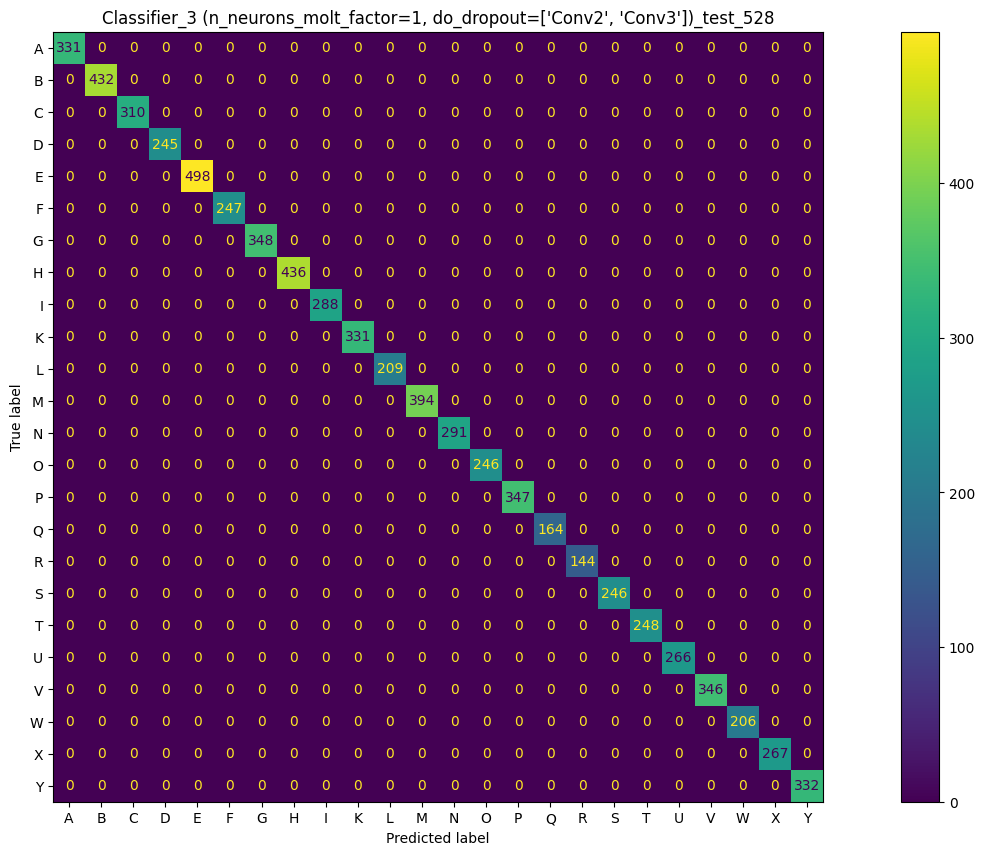

1.0
WRONG PREDICTIONS:


In [9]:
best_model = NeuralNetwork.load_NN(all_results.iloc[13968], classifiers_dict, torch.device("cuda"), (28,28))
best_model.explore_wrong_predictions()

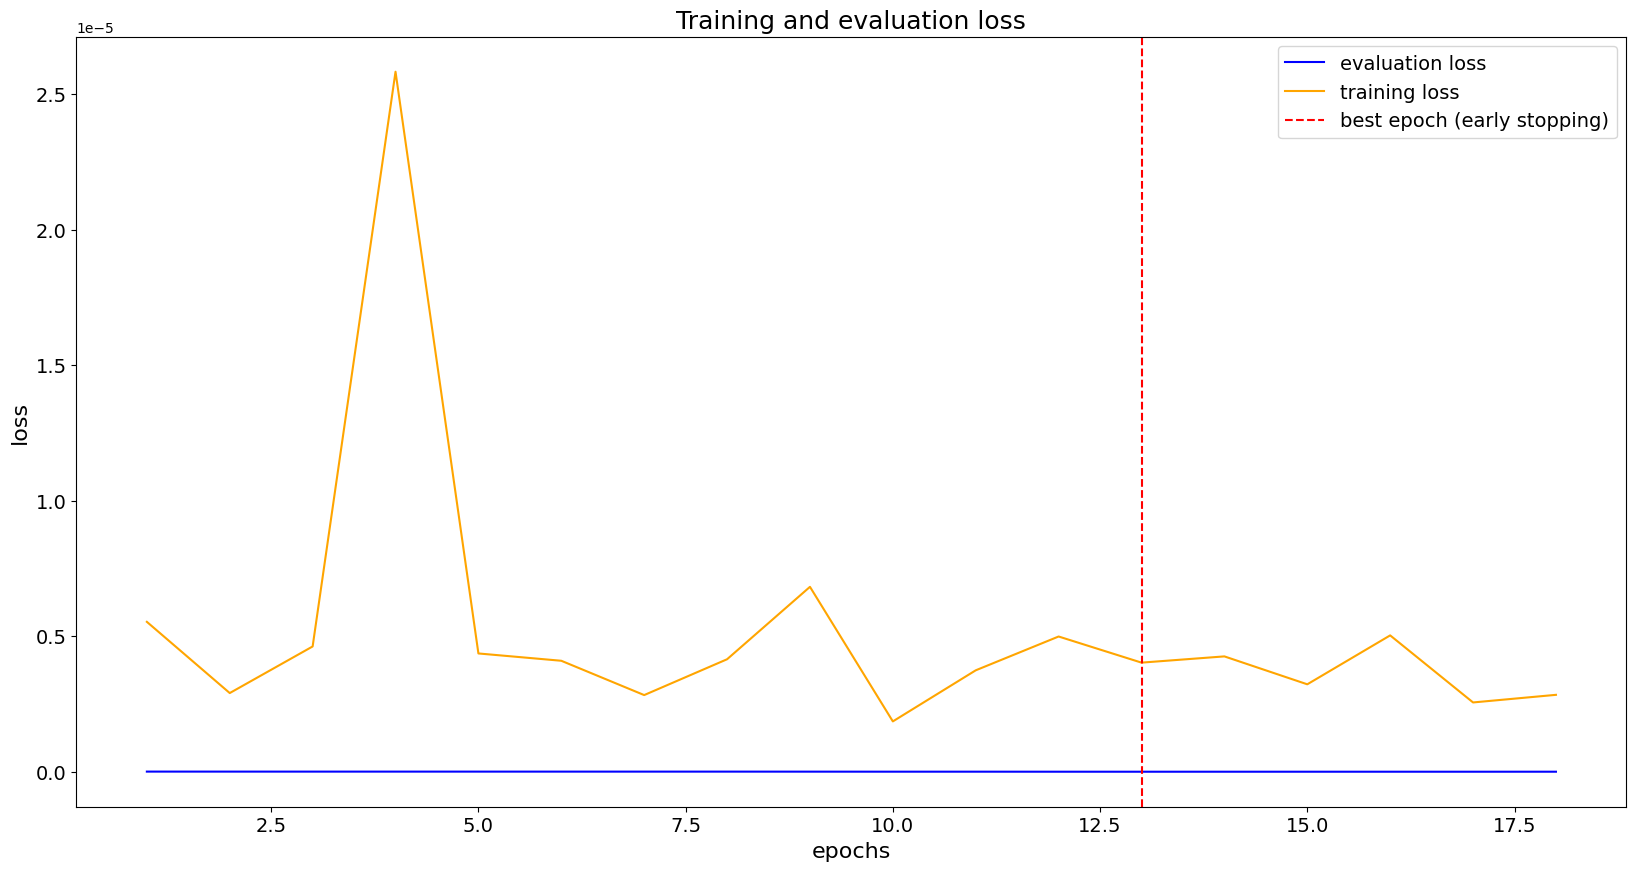

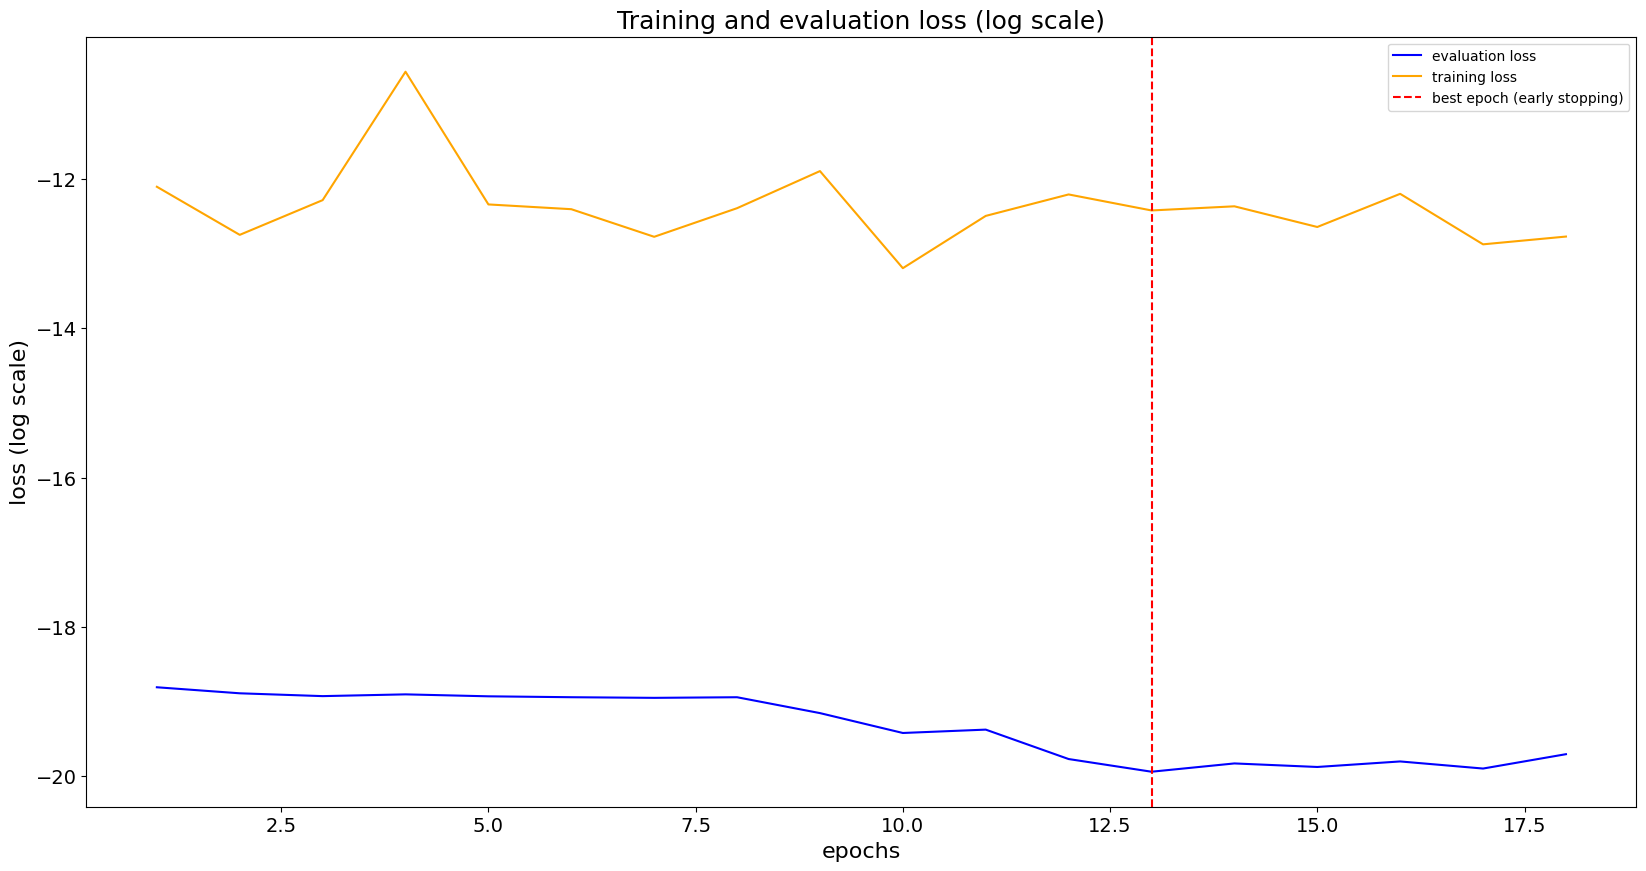

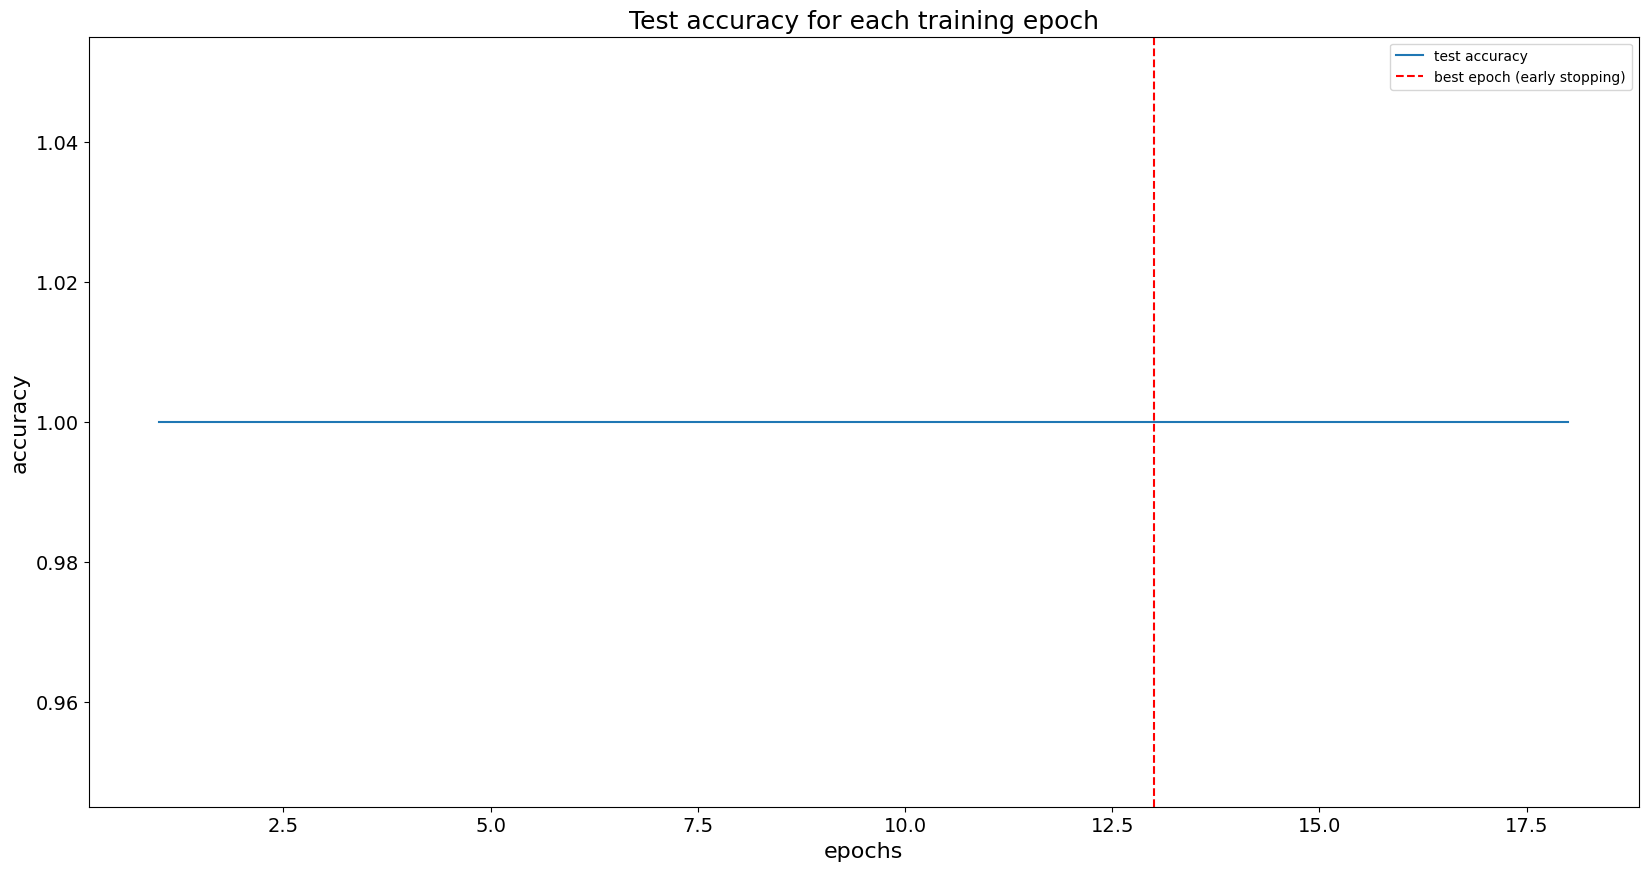

In [10]:
best_model.plot_metrics()

In [11]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,optimizer,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,2.0,['Conv2'],AMSGrad,0.0005,32,5,0.00,0.020078,0.082985,10.274774
3623,423,5,1.0,[],ADAM,0.0001,64,10,0.75,0.020078,0.058788,10.663838
3624,424,5,1.0,[],ADAM,0.0001,64,15,0.00,0.020078,0.058362,9.247431
3625,425,5,1.0,[],ADAM,0.0001,64,15,0.25,0.020078,0.058631,15.616779
3626,426,5,1.0,[],ADAM,0.0001,64,15,0.50,0.020078,0.058452,13.478697
3627,427,5,1.0,[],ADAM,0.0001,64,15,0.75,0.020078,0.058227,15.603582
3628,428,5,1.0,[],ADAM,0.0001,64,20,0.00,0.020078,0.058685,12.119834
3629,429,5,1.0,[],ADAM,0.0001,64,20,0.25,0.020078,0.058553,14.656565
3622,422,5,1.0,[],ADAM,0.0001,64,10,0.50,0.020078,0.058444,9.277871
3630,430,5,1.0,[],ADAM,0.0001,64,20,0.50,0.020078,0.058709,17.561255


In [12]:
n_low_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].min()])
n_low_accuracy_architectures

1280

In [13]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(n_low_accuracy_architectures)["architecture_id"].unique()

array([0, 5])

In [14]:
architecture_stats(all_results, classifiers_dict, 0)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2']) (id: 0)
mean accuracy: 0.0201 with standard error: 0.0000

worst accuracy: 0.0201 with hyperparameters:
test_id                           0
optimizer                   AMSGrad
lr                           0.0005
batch_size                       32
patience                          5
data_augmentation_perc          0.0
test_times                 0.082985
train_times               10.274774
Name: 0, dtype: object 

best accuracy: 0.0201 with hyperparameters:
test_id                           0
optimizer                   AMSGrad
lr                           0.0005
batch_size                       32
patience                          5
data_augmentation_perc          0.0
test_times                 0.082985
train_times               10.274774
Name: 0, dtype: object 



In [19]:
architecture_stats(all_results, classifiers_dict, 5)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=1, do_dropout=[]) (id: 5)
mean accuracy: 0.0201 with standard error: 0.0000

worst accuracy: 0.0201 with hyperparameters:
test_id                          0
optimizer                  AMSGrad
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc         0.0
test_times                0.081855
train_times               8.576346
Name: 3200, dtype: object 

best accuracy: 0.0201 with hyperparameters:
test_id                          0
optimizer                  AMSGrad
lr                          0.0005
batch_size                      32
patience                         5
data_augmentation_perc         0.0
test_times                0.081855
train_times               8.576346
Name: 3200, dtype: object 



Loaded model: Classifier_3 (n_neurons_molt_factor=2, do_dropout=['Conv2'])_test_0


Architecture:
name: Classifier_3 (n_neurons_molt_factor=2.0, do_dropout=['Conv2'])
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 12, 12]          --
|    └─Conv2d: 2-1                       [-1, 32, 24, 24]          832
|    └─MaxPool2d: 2-2                    [-1, 32, 12, 12]          --
|    └─ReLU: 2-3                         [-1, 32, 12, 12]          --
├─Sequential: 1-2                        [-1, 64, 4, 4]            --
|    └─Conv2d: 2-4                       [-1, 64, 8, 8]            51,264
|    └─MaxPool2d: 2-5                    [-1, 64, 4, 4]            --
|    └─ReLU: 2-6                         [-1, 64, 4, 4]            --
|    └─Dropout: 2-7                      [-1, 64, 4, 4]            --
├─Sequential: 1-3                        [-1, 128, 1, 1]           --
|    └─Conv2d: 2-8                       [-1, 128, 2,

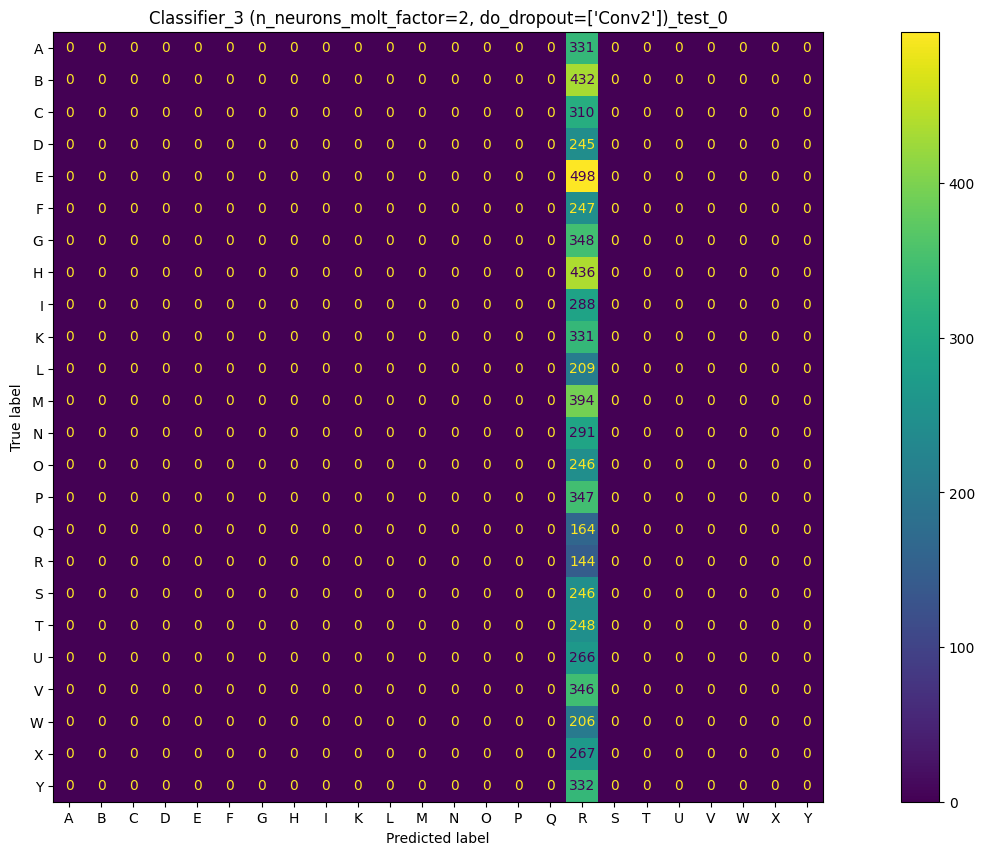

0.020078081427774678


In [15]:
NeuralNetwork.load_NN(all_results.iloc[0], classifiers_dict, torch.device("cuda"), (28,28)).plot_confusion_matrix()

In [16]:
all_results.sort_values(by=['test_accuracies'], ascending=True).iloc[320:330]

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,optimizer,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
3519,319,5,1.0,[],AMSGrad,0.000001,512,20,0.75,0.020078,0.041126,15.691619
3302,102,5,1.0,[],AMSGrad,0.000100,64,10,0.50,0.020078,0.058459,73.955264
3303,103,5,1.0,[],AMSGrad,0.000100,64,10,0.75,0.020078,0.058180,10.743502
3304,104,5,1.0,[],AMSGrad,0.000100,64,15,0.00,0.020078,0.058552,9.281348
3305,105,5,1.0,[],AMSGrad,0.000100,64,15,0.25,0.020078,0.058268,11.446823
3306,106,5,1.0,[],AMSGrad,0.000100,64,15,0.50,0.020078,0.058471,13.629525
3307,107,5,1.0,[],AMSGrad,0.000100,64,15,0.75,0.020078,0.058398,15.689444
3308,108,5,1.0,[],AMSGrad,0.000100,64,20,0.00,0.020078,0.058522,16.873129
3301,101,5,1.0,[],AMSGrad,0.000100,64,10,0.25,0.020078,0.058436,7.493253
3309,109,5,1.0,[],AMSGrad,0.000100,64,20,0.25,0.020078,0.058552,18.568138


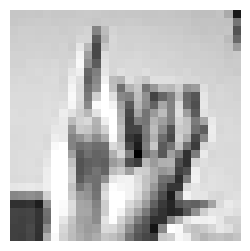

True label: I


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 1.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

In [17]:
image, response = sample_image(index = 10)
best_model.predict(image)